<a href="https://colab.research.google.com/github/Shizukem/B-i-12/blob/main/b%C3%A0i_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving vietnam_macro_2020_2025.csv to vietnam_macro_2020_2025 (1).csv


In [ ]:
import numpy as np
import pandas as pd

# Dữ liệu đầu vào (được chuyển từ cell ufVrLO9SBTjt)
data = {
    'Year': [2020, 2021, 2022, 2023, 2024, 2025],
    'Y': [8044.4, 8487.5, 9513.3, 10221.8, 11511.9, 12847.6],  # GDP (nghìn tỷ VND)
    'K': [16500, 17800, 19600, 21300, 23500, 25900],  # Vốn tích lũy (nghìn tỷ)
    'L': [53.6, 50.5, 51.7, 52.4, 52.9, 53.4],  # Lao động (triệu người)
    'D': [12.0, 12.7, 14.3, 16.5, 18.3, 19.5],  # Kinh tế số/GDP (%)
    'AI': [55.6, 60.2, 65.4, 67.0, 73.8, 80.1],  # DN số (nghìn)
    'H': [24.1, 26.1, 26.2, 27.0, 28.4, 29.2]  # LĐ qua đào tạo (%)
}

df = pd.DataFrame(data)

# Hệ số Cobb-Douglas (được chuyển từ cell ufVrLO9SBTjt)
alpha = 0.33  # Độ co giãn theo vốn vật chất
beta = 0.42   # Độ co giãn theo lao động
gamma = 0.10  # Độ co giãn theo số hóa
delta = 0.08  # Độ co giãn theo AI
theta = 0.07  # Độ co giãn theo vốn nhân lực

# Trích xuất các biến từ DataFrame df
Y = df['Y']
K = df['K']
L = df['L']
D = df['D']
AI = df['AI']
H = df['H']
years = df['Year']

# CÂU 1.4.1 — Ước lượng TFP (A_t)
# ─────────────────────────────────────────────────────────────────
print("\n[ Câu 1.4.1 ] ─ Ước lượng năng suất nhân tố tổng hợp TFP (A_t)")
print("-" * 55)

# A_t = Y / (K**alpha * L**beta * D**gamma * AI**delta * H**theta)
A = Y / (K**alpha * L**beta * D**gamma * AI**delta * H**theta)

df_tfp = pd.DataFrame({'Năm': years, 'GDP (nghìn tỷ)': Y, 'TFP A_t': A})
print(df_tfp.to_string(index=False, float_format='%.4f'))

A_mean = A.mean()
print(f"\n  → TFP trung bình 2020-2025: {A_mean:.4f}")
trend = np.polyfit(years, A, 1)
print(f"  → Xu hướng TFP: {'tăng' if trend[0] > 0 else 'giảm'} ({trend[0]:+.4f}/năm)")


[ Câu 1.4.1 ] ─ Ước lượng năng suất nhân tố tổng hợp TFP (A_t)
-------------------------------------------------------
 Năm  GDP (nghìn tỷ)  TFP A_t
2020       8044.4000  27.7466
2021       8487.5000  28.7638
2022       9513.3000  30.3501
2023      10221.8000  30.9751
2024      11511.9000  32.9171
2025      12847.6000  34.9136

  → TFP trung bình 2020-2025: 30.9444
  → Xu hướng TFP: tăng (+1.3977/năm)


In [ ]:
print("\n[ Câu 1.4.2 ] ─ So sánh GDP dự báo vs. thực tế, tính MAPE")
print("-" * 55)

Y_hat = A_mean * (K**alpha * L**beta * D**gamma * AI**delta * H**theta)
MAPE  = np.mean(np.abs((Y - Y_hat) / Y)) * 100

df_compare = pd.DataFrame({
    'Năm':          years,
    'GDP thực (nghìn tỷ)': Y,
    'GDP dự báo':   Y_hat,
    'Sai lệch (%)': np.abs((Y - Y_hat) / Y) * 100
})
print(df_compare.to_string(index=False, float_format='%.2f'))
print(f"\n  → MAPE = {MAPE:.4f}%")


[ Câu 1.4.2 ] ─ So sánh GDP dự báo vs. thực tế, tính MAPE
-------------------------------------------------------
 Năm  GDP thực (nghìn tỷ)  GDP dự báo  Sai lệch (%)
2020              8044.40     8971.52         11.53
2021              8487.50     9130.94          7.58
2022              9513.30     9699.59          1.96
2023             10221.80    10211.65          0.10
2024             11511.90    10822.00          5.99
2025             12847.60    11386.99         11.37

  → MAPE = 6.4209%


In [ ]:
print("\n[ Câu 1.4.3 ] ─ Phân rã tăng trưởng GDP 2021-2025")
print("-" * 55)

# Δln(X) ≈ tỷ lệ tăng trưởng của X
dln_Y  = np.diff(np.log(Y))
dln_K  = np.diff(np.log(K))
dln_L  = np.diff(np.log(L))
dln_D  = np.diff(np.log(D))
dln_AI = np.diff(np.log(AI))
dln_H  = np.diff(np.log(H))

contrib_K  = alpha * dln_K
contrib_L  = beta  * dln_L
contrib_D  = gamma * dln_D
contrib_AI = delta * dln_AI
contrib_H  = theta * dln_H
contrib_TFP = dln_Y - contrib_K - contrib_L - contrib_D - contrib_AI - contrib_H

years_delta = years[1:]
df_growth = pd.DataFrame({
    'Năm':    years_delta,
    'ΔlnY':   dln_Y  * 100,
    'K (%)':  contrib_K  * 100,
    'L (%)':  contrib_L  * 100,
    'D (%)':  contrib_D  * 100,
    'AI (%)': contrib_AI * 100,
    'H (%)':  contrib_H  * 100,
    'TFP (%)':contrib_TFP * 100,
})
print(df_growth.to_string(index=False, float_format='%.3f'))

# Bình quân hàng năm
avg_contrib = {
    'Vốn K':      contrib_K.mean()  * 100,
    'Lao động L': contrib_L.mean()  * 100,
    'Số hóa D':   contrib_D.mean()  * 100,
    'AI':         contrib_AI.mean() * 100,
    'Nhân lực H': contrib_H.mean()  * 100,
    'TFP':        contrib_TFP.mean()* 100,
}
total_avg = dln_Y.mean() * 100
print(f"\n  Tổng tăng trưởng GDP bình quân/năm: {total_avg:.3f}%")
print("\n  Đóng góp bình quân (điểm % / năm):")
for k, v in avg_contrib.items():
    pct_share = v / total_avg * 100
    print(f"    {k:<14}: {v:+.3f} pp   ({pct_share:+.1f}% tổng tăng trưởng)")


[ Câu 1.4.3 ] ─ Phân rã tăng trưởng GDP 2021-2025
-------------------------------------------------------
 Năm   ΔlnY  K (%)  L (%)  D (%)  AI (%)  H (%)  TFP (%)
2021  5.362  2.503 -2.502  0.567   0.636  0.558    3.600
2022 11.410  3.179  0.986  1.187   0.663  0.027    5.368
2023  7.183  2.745  0.565  1.431   0.193  0.211    2.039
2024 11.886  3.244  0.399  1.035   0.773  0.354    6.081
2025 10.978  3.209  0.395  0.635   0.655  0.194    5.889

  Tổng tăng trưởng GDP bình quân/năm: 9.364%

  Đóng góp bình quân (điểm % / năm):
    Vốn K         : +2.976 pp   (+31.8% tổng tăng trưởng)
    Lao động L    : -0.031 pp   (-0.3% tổng tăng trưởng)
    Số hóa D      : +0.971 pp   (+10.4% tổng tăng trưởng)
    AI            : +0.584 pp   (+6.2% tổng tăng trưởng)
    Nhân lực H    : +0.269 pp   (+2.9% tổng tăng trưởng)
    TFP           : +4.595 pp   (+49.1% tổng tăng trưởng)


In [ ]:
print("\n[ Câu 1.4.4 ] ─ Dự báo GDP Việt Nam 2030")
print("-" * 55)

# TFP tăng 1.2%/năm từ 2025
A_2030  = A.iloc[-1] * (1 + 0.012) ** 5      # 5 năm từ 2025→2030
K_2030  = K.iloc[-1] * (1 + 0.06)  ** 5
L_2030  = L.iloc[-1] * (1 + 0.006) ** 5      # L tăng khoảng 0.6%/năm
D_2030  = 30.0                           # mục tiêu 30%
AI_2030 = 100.0                          # 100 nghìn DN số
H_2030  = 35.0                           # 35% LĐ qua đào tạo

Y_2030 = A_2030 * (K_2030**alpha * L_2030**beta * D_2030**gamma
                   * AI_2030**delta * H_2030**theta)

print(f"  Giả định đến 2030:")
print(f"    K_2030  = {K_2030:,.1f} nghìn tỷ VND  (+6%/năm)")
print(f"    L_2030  = {L_2030:.2f} triệu người   (+~0.6%/năm)")
print(f"    D_2030  = {D_2030:.1f}% GDP           (mục tiêu QĐ 749)")
print(f"    AI_2030 = {AI_2030:.0f} nghìn DN số")
print(f"    H_2030  = {H_2030:.1f}% LĐ qua đào tạo")
print(f"    A_2030  = {A_2030:.4f}  (+1.2%/năm)")
print(f"\n  → GDP dự báo 2030: {Y_2030:,.1f} nghìn tỷ VND")
print(f"  → Tăng trưởng kép 2025-2030: {((Y_2030/Y.iloc[-1])**(1/5)-1)*100:.2f}%/năm")


[ Câu 1.4.4 ] ─ Dự báo GDP Việt Nam 2030
-------------------------------------------------------
  Giả định đến 2030:
    K_2030  = 34,660.0 nghìn tỷ VND  (+6%/năm)
    L_2030  = 55.02 triệu người   (+~0.6%/năm)
    D_2030  = 30.0% GDP           (mục tiêu QĐ 749)
    AI_2030 = 100 nghìn DN số
    H_2030  = 35.0% LĐ qua đào tạo
    A_2030  = 37.0593  (+1.2%/năm)

  → GDP dự báo 2030: 16,362.9 nghìn tỷ VND
  → Tăng trưởng kép 2025-2030: 4.96%/năm


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 20))
fig.patch.set_facecolor('white')
gs = GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.32)

<Figure size 1800x2000 with 0 Axes>

In [ ]:
COLOR_MAIN = '#3498db'
COLOR_ACCENT = '#e74c3c'
COLOR_GREEN = '#2ecc71'

In [ ]:
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(years, A, 'o-', color=COLOR_MAIN, lw=2.5, ms=8, label='TFP A_t (thực tế)')
ax1.axhline(A_mean, color=COLOR_ACCENT, ls='--', lw=1.8, label=f'TFP trung bình = {A_mean:.4f}')
trend_line = np.poly1d(trend)
ax1.plot(years, trend_line(years), ':', color=COLOR_GREEN, lw=1.8, label='Xu hướng')
for yr, a_val in zip(years, A):
    ax1.annotate(f'{a_val:.3f}', (yr, a_val),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9.5, color=COLOR_MAIN, fontweight='bold')
ax1.set_title('Câu 1.4.1 — Năng suất nhân tố tổng hợp TFP (A_t)')
ax1.set_xlabel('Năm')
ax1.set_ylabel('TFP A_t')
ax1.set_xticks(years)
ax1.legend(fontsize=9)
ax1.set_ylim(A.min() * 0.97, A.max() * 1.05)

(26.914181537878495, 36.65930217014775)

In [ ]:
import matplotlib.ticker as mticker

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(years, Y, 'o-', color=COLOR_MAIN, lw=2.5, ms=8, label='GDP thực tế')
ax2.plot(years, Y_hat, 's--', color=COLOR_ACCENT, lw=2, ms=7, label='GDP dự báo (A̅)')
ax2.fill_between(years, Y, Y_hat, alpha=0.15, color=COLOR_ACCENT, label='Sai số')
ax2.set_title(f'Câu 1.4.2 — GDP thực tế vs. Dự báo  (MAPE = {MAPE:.3f}%)')
ax2.set_xlabel('Năm')
ax2.set_ylabel('GDP (nghìn tỷ VND)')
ax2.set_xticks(years)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.legend(fontsize=9)

In [ ]:
ax3 = fig.add_subplot(gs[1, :])
components = {
    'Vốn K':      contrib_K  * 100,
    'Lao động L': contrib_L  * 100,
    'Số hóa D':   contrib_D  * 100,
    'AI':         contrib_AI * 100,
    'Nhân lực H': contrib_H  * 100,
    'TFP':        contrib_TFP* 100,
}
bar_colors = ['#2980b9','#e74c3c','#27ae60','#f39c12','#8e44ad','#16a085']
bottoms_pos = np.zeros(len(years_delta))
bottoms_neg = np.zeros(len(years_delta))

for (label, vals), col in zip(components.items(), bar_colors):
    pos_vals = np.where(vals >= 0, vals, 0)
    neg_vals = np.where(vals < 0, vals, 0)
    ax3.bar(years_delta, pos_vals, bottom=bottoms_pos, color=col,
            label=label, alpha=0.88, width=0.6)
    ax3.bar(years_delta, neg_vals, bottom=bottoms_neg, color=col,
            alpha=0.88, width=0.6)
    bottoms_pos += pos_vals
    bottoms_neg += neg_vals

ax3.plot(years_delta, dln_Y * 100, 'D--', color='black',
         lw=2, ms=8, label='Tổng tăng trưởng GDP', zorder=5)
ax3.axhline(0, color='black', lw=0.8)
ax3.set_title('Câu 1.4.3 — Phân rã tăng trưởng GDP theo yếu tố đóng góp (pp/năm)')
ax3.set_xlabel('Năm')
ax3.set_ylabel('Điểm phần trăm đóng góp (%)')
ax3.set_xticks(years_delta)
ax3.legend(loc='upper left', fontsize=9, ncol=4)

In [ ]:
ax4 = fig.add_subplot(gs[2, 0])
avg_vals  = list(avg_contrib.values())
avg_names = list(avg_contrib.keys())
bar_colors4 = ['#2980b9','#e74c3c','#27ae60','#f39c12','#8e44ad','#16a085']
bars = ax4.bar(avg_names, avg_vals, color=bar_colors4, alpha=0.88, width=0.6, zorder=3)
ax4.axhline(0, color='black', lw=0.8)
for bar, v in zip(bars, avg_vals):
    ax4.text(bar.get_x() + bar.get_width()/2,
             v + (0.02 if v >= 0 else -0.05),
             f'{v:+.3f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
ax4.set_title('Câu 1.4.3 — Đóng góp bình quân/năm\nvào tăng trưởng GDP (%)')
ax4.set_ylabel('Điểm phần trăm (pp)')
ax4.tick_params(axis='x', rotation=18)

In [ ]:
ax5 = fig.add_subplot(gs[2, 1])
years_full = np.append(years, 2030)
Y_full     = np.append(Y, Y_2030)
ax5.plot(years, Y, 'o-', color=COLOR_MAIN,   lw=2.5, ms=8, label='GDP thực tế 2020-2025')
ax5.plot([2025, 2030], [Y.iloc[-1], Y_2030], 's--', color=COLOR_ACCENT,
         lw=2.5, ms=10, label=f'GDP dự báo 2030\n≈ {Y_2030:,.0f} nghìn tỷ')
ax5.scatter([2030], [Y_2030], color=COLOR_ACCENT, s=120, zorder=6)
ax5.annotate(f'{Y_2030:,.0f}\nnghìn tỷ', (2030, Y_2030),
             textcoords='offset points', xytext=(-55, 12),
             fontsize=10, color=COLOR_ACCENT, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLOR_ACCENT))
ax5.fill_between([2025, 2030], [Y.iloc[-1]*0.95, Y_2030*0.95],
                 [Y.iloc[-1]*1.05, Y_2030*1.05],
                 alpha=0.12, color=COLOR_ACCENT, label='Dải bất định ±5%')
ax5.set_title('Câu 1.4.4 — Dự báo GDP Việt Nam đến 2030')
ax5.set_xlabel('Năm')
ax5.set_ylabel('GDP (nghìn tỷ VND)')
ax5.set_xticks(years_full)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax5.legend(fontsize=9)

In [ ]:
import os
import matplotlib.pyplot as plt

output_dir = '/mnt/user-data/outputs'
os.makedirs(output_dir, exist_ok=True)

# Save as PNG
fig.savefig(os.path.join(output_dir, 'vietnam_gdp_analysis.png'), dpi=300, bbox_inches='tight')
print(f"✓ Đã lưu biểu đồ tổng hợp sang: {os.path.join(output_dir, 'vietnam_gdp_analysis.png')}")

# Save as PDF
fig.savefig(os.path.join(output_dir, 'vietnam_gdp_analysis.pdf'), bbox_inches='tight')
print(f"✓ Đã lưu biểu đồ tổng hợp sang: {os.path.join(output_dir, 'vietnam_gdp_analysis.pdf')}")

plt.show()

✓ Đã lưu biểu đồ tổng hợp sang: /mnt/user-data/outputs/vietnam_gdp_analysis.png
✓ Đã lưu biểu đồ tổng hợp sang: /mnt/user-data/outputs/vietnam_gdp_analysis.pdf


Displaying vietnam_gdp_analysis.png:


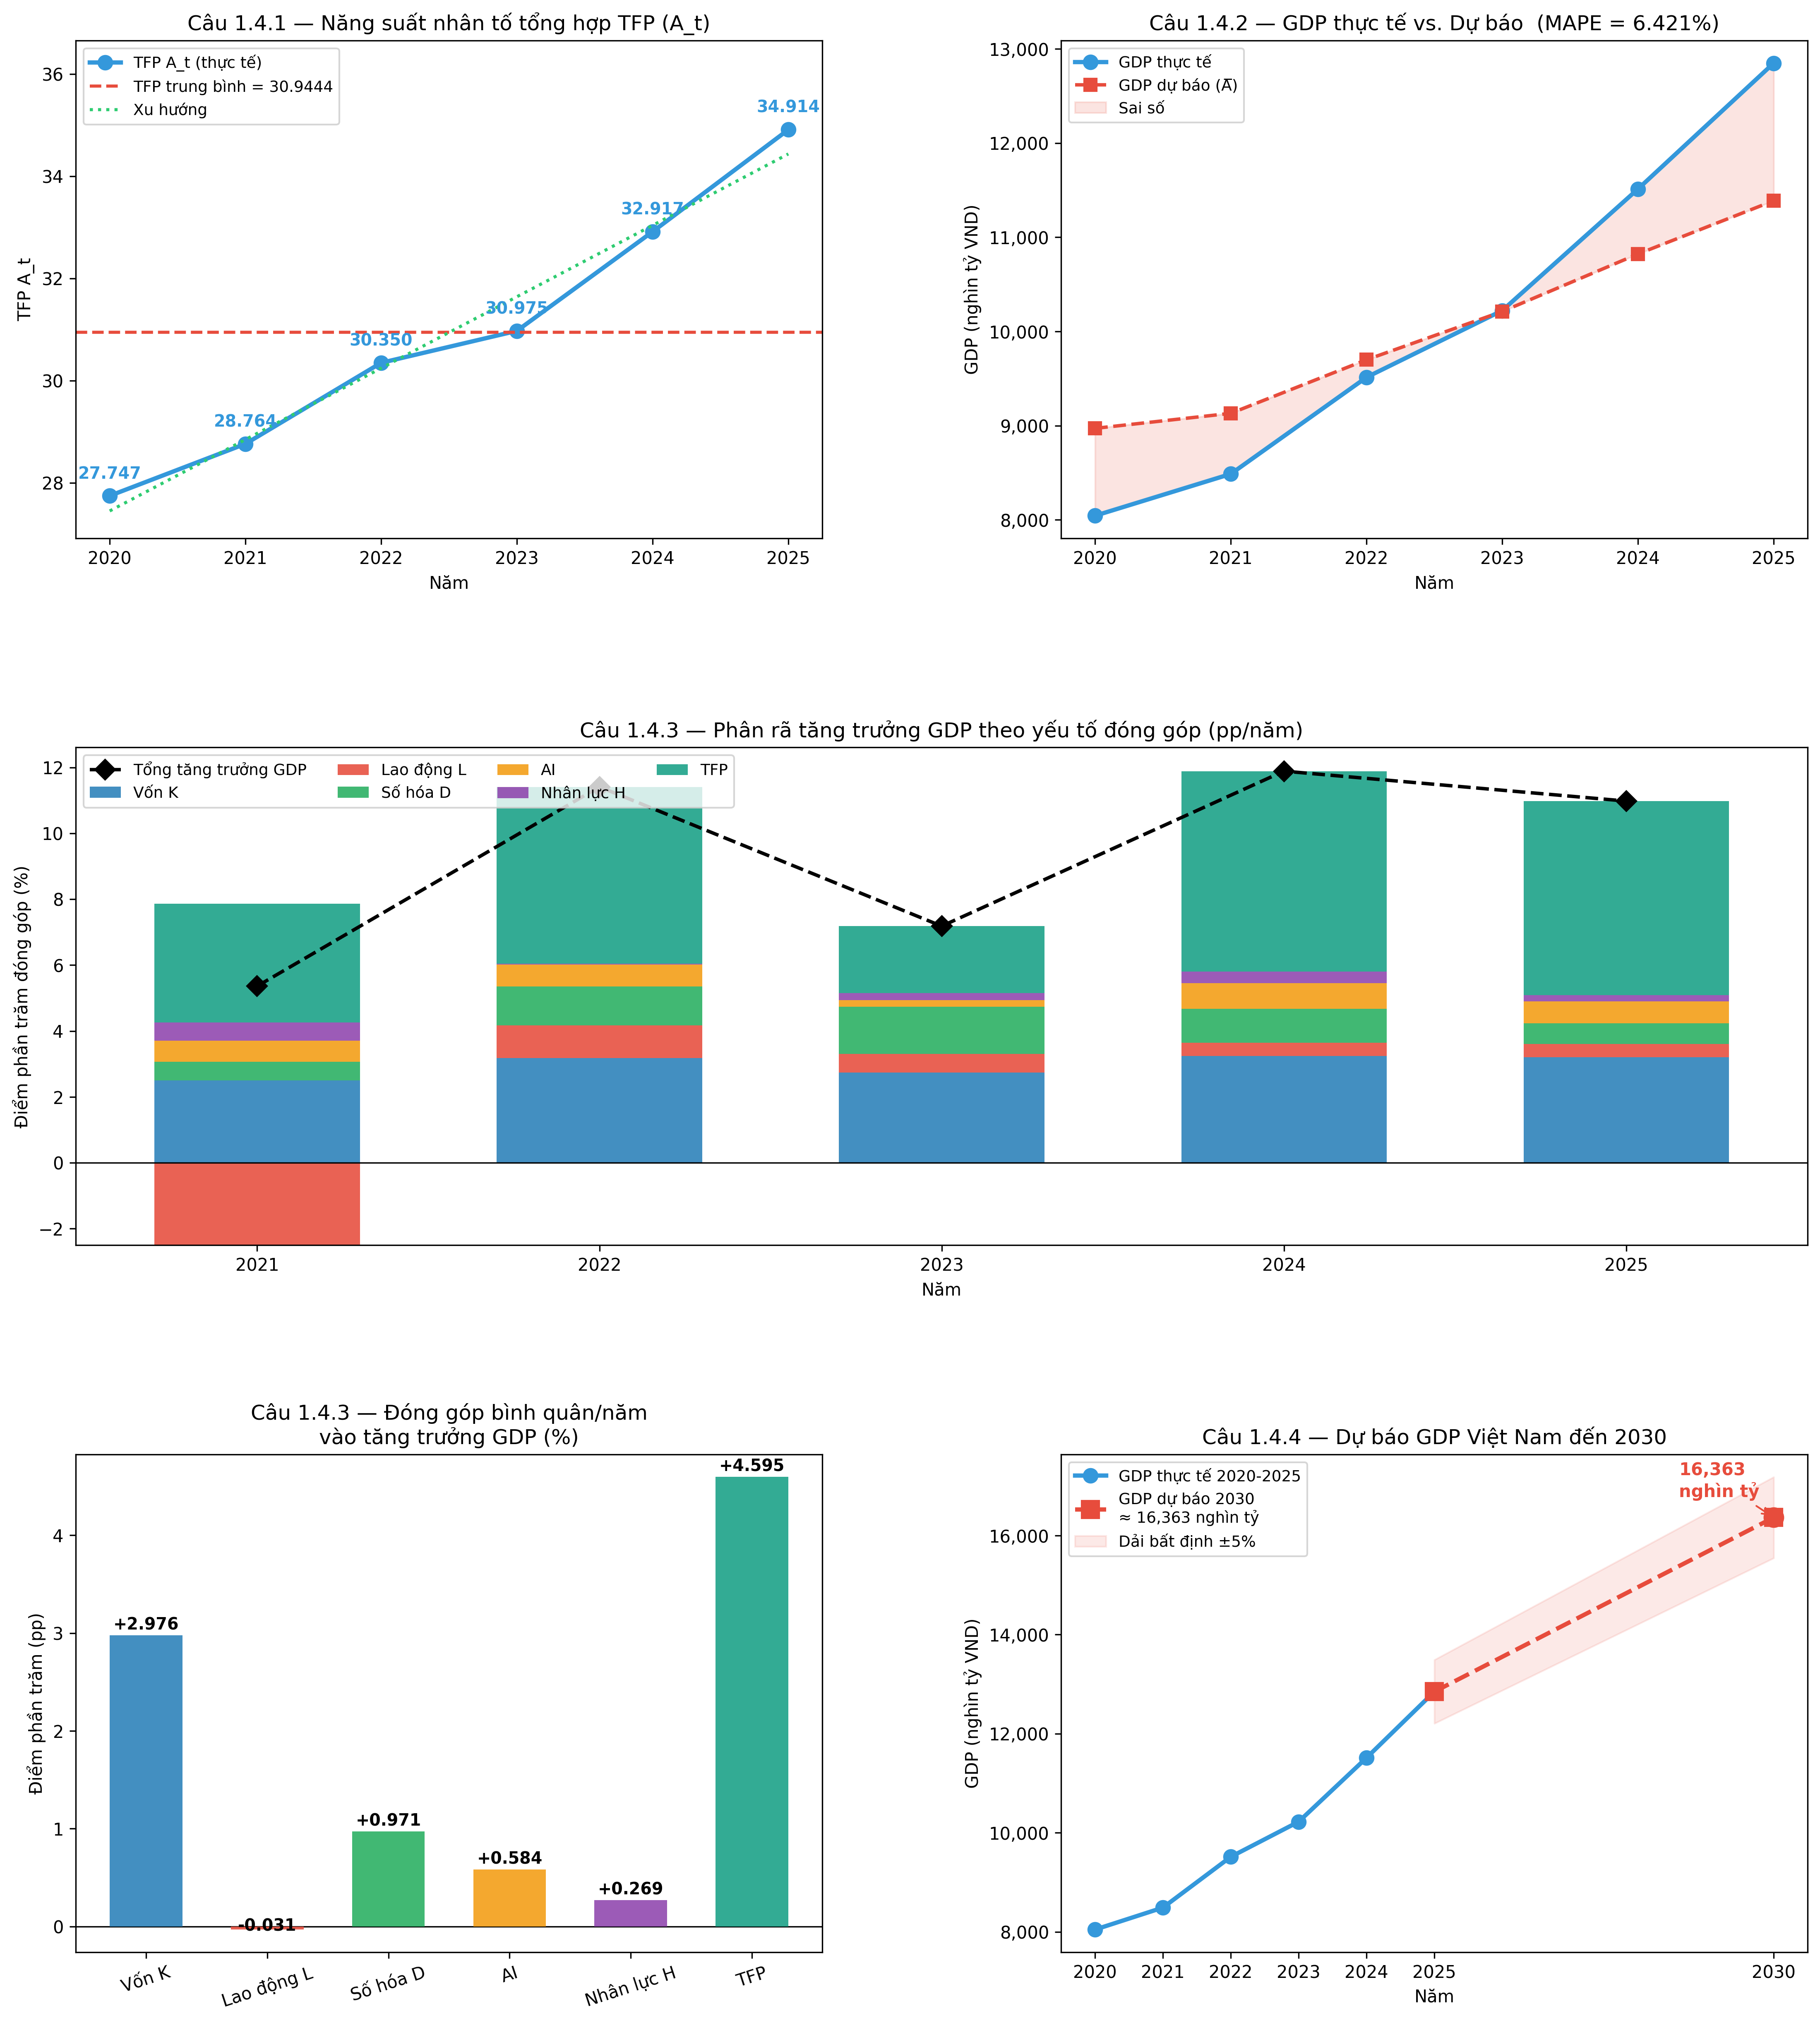

In [ ]:
from IPython.display import Image, display

output_dir = '/mnt/user-data/outputs'

print('Displaying vietnam_gdp_analysis.png:')
display(Image(filename=f'{output_dir}/vietnam_gdp_analysis.png'))